# Bootstrap .venv and verify a TPU runtime receipt

CPU companion; no accelerator is required. TPU execution not validated.

- Bootstrap `~/jax-tpu-lab/.venv` on a Cloud TPU VM and install `jax[tpu]` from the official `libtpu` wheel index.
- Verify `jax.default_backend()`, `jax.device_count()`, and a synchronized `jax.pmap` reduction across 1, 4, or 8 chips.
- Copy the JSON runtime receipt back to your workstation with `gcloud compute tpus tpu-vm scp`.
- Delete the Cloud TPU VM and confirm with `gcloud compute tpus tpu-vm list` that zero billable TPU nodes remain.

After `gcloud compute tpus tpu-vm create` reports `READY`, you still cannot trust a benchmark or training job until Python inside your TPU VM's `.venv` proves it can load `libtpu`, see all attached TPU chips, execute a synchronized collective across them, and tear down cleanly so nothing keeps billing.

## The idea

Bootstrap an isolated `~/jax-tpu-lab/.venv` on the TPU VM Linux host with `jax[tpu]`, run a deterministic `jax.pmap` runtime receipt across all local chips, copy the receipt back to your laptop with `gcloud compute tpus tpu-vm scp`, and delete the TPU VM (`tpu-vm delete` + `tpu-vm list`) whenever your session ends.

## Why a synchronized `pmap` receipt is stronger than `import jax`

Importing `jax` on a Cloud TPU VM only proves that the Python package is installed on the Linux host. To prove that `libtpu` can initialize the attached TPU chips, allocate High Bandwidth Memory (HBM), compile an XLA HLO computation, and synchronize results back to the host, you should run a small `jax.pmap` reduction across `jax.local_devices()` and call `jax.block_until_ready`.

If each device $d \in \{0, \dots, D-1\}$ receives a slice of $8$ consecutive integers starting at $8d$, then across $D$ devices the global vector contains $0, 1, \dots, 8D - 1$, and the exact sum of squares is:
$$

S(D) = \sum_{k=0}^{8D - 1} k^2 = \frac{(8D - 1)(8D)(16D - 1)}{6}

$$
Checking that the `pmap` result equals $S(D)$ (for example, $S(1) = 140$, $S(4) = 10416$, $S(8) = 85344$) verifies both device discovery and multi-chip execution in one step.

### Pause and reason

What happens if you close your SSH terminal without running `gcloud compute tpus tpu-vm delete`?

<details><summary>Compare your reasoning</summary>

The Cloud TPU VM stays allocated in the `READY` state and continues billing every hour even when no Python process or SSH session is active. Always delete the TPU VM and verify with `gcloud compute tpus tpu-vm list`.

</details>

## 1. Bootstrap `~/jax-tpu-lab/.venv` and install `jax[tpu]` over SSH

Use `gcloud compute tpus tpu-vm ssh` to create a dedicated virtual environment on the TPU VM host and install `jax[tpu]` plus the course libraries (`flax`, `optax`, `orbax-checkpoint`, `numpy`, `matplotlib`).

**Create ~/jax-tpu-lab/.venv and install jax[tpu] on the Cloud TPU VM**

```bash
# Create ~/jax-tpu-lab/.venv and install jax[tpu] on the Cloud TPU VM
gcloud compute tpus tpu-vm ssh "$TPU_NAME" --zone="$ZONE" --command="
  set -euo pipefail
  mkdir -p ~/jax-tpu-lab
  python3 -m venv ~/jax-tpu-lab/.venv
  source ~/jax-tpu-lab/.venv/bin/activate
  pip install -U pip
  pip install 'jax[tpu]' -f https://storage.googleapis.com/jax-releases/libtpu_releases.html
  pip install flax optax orbax-checkpoint numpy matplotlib
"
```

**Expected:** Installs jax[tpu], libtpu, and the course dependencies inside ~/jax-tpu-lab/.venv on the TPU VM.

## 2. Run the runtime receipt script, copy the JSON receipt back, and delete the TPU VM

Stage `public/exercises/tpu-04.py` to the TPU VM, run it inside `~/jax-tpu-lab/.venv`, copy the saved receipt back to your workstation, and delete the TPU VM when finished.

**Run the runtime receipt verifier on the TPU VM and copy the receipt home**

```bash
# Run the runtime receipt verifier on the TPU VM and copy the receipt home
gcloud compute tpus tpu-vm scp public/exercises/tpu-04.py "$TPU_NAME":~/jax-tpu-lab/ --zone="$ZONE"
gcloud compute tpus tpu-vm ssh "$TPU_NAME" --zone="$ZONE" \
  --command="JAX_PLATFORMS=tpu ~/jax-tpu-lab/.venv/bin/python ~/jax-tpu-lab/tpu-04.py | tee ~/jax-tpu-lab/tpu-receipt.txt"
gcloud compute tpus tpu-vm scp "$TPU_NAME":~/jax-tpu-lab/tpu-receipt.txt ./ --zone="$ZONE"
```

**Expected:** Runs tpu-04.py on the TPU VM, writes tpu-receipt.txt, and downloads it to your current directory.

**Delete the Cloud TPU VM and verify zero active TPU resources remain**

```bash
# Delete the Cloud TPU VM and verify zero active TPU resources remain
gcloud compute tpus tpu-vm delete "$TPU_NAME" --zone="$ZONE" --quiet
gcloud compute tpus tpu-vm list --zone="$ZONE"
```

**Expected:** Deletes the TPU VM and prints Listed 0 items.

## Define the closed-form sum-of-squares oracle and pmap receipt builder

Create main.py with closed_form_sum_of_squares and build_runtime_receipt.

In [1]:
# Step 1 — Define the closed-form sum-of-squares oracle and pmap receipt builder: Each local device computes the sum of squares of its 8-element row...
# Import hashlib for this computation.
import hashlib
import json
import platform
import jax
import jax.numpy as jnp
import numpy as np


# Function `closed_form_sum_of_squares(num_devices, width)` implementing this stage's computation:
def closed_form_sum_of_squares(num_devices, width=8):
    # Evaluate `num_devices) * int(width` and convert the result into Python scalar/collection `n`.
    n = int(num_devices) * int(width)
    # Return `float((n - 1) * n * (2 * n - 1) // 6)` to the caller.
    return float((n - 1) * n * (2 * n - 1) // 6)


# Function `build_runtime_receipt()` implementing this stage's computation:
def build_runtime_receipt():
    # Query the active JAX devices into `devices`.
    devices = jax.local_devices()
    # Run `len` to compute `n_dev`.
    n_dev = len(devices)
    # Construct and reshape `x` into the target tensor dimensions.
    x = jnp.arange(n_dev * 8, dtype=jnp.float32).reshape(n_dev, 8)
    # Reduce across the target axis to summarize `per_device`.
    per_device = jax.pmap(lambda row: jnp.sum(row * row))(x)
    # Synchronize host execution until asynchronous device computation completes.
    observed_total = float(jax.block_until_ready(jnp.sum(per_device)))
    # Run `closed_form_sum_of_squares` to compute `expected_total`.
    expected_total = closed_form_sum_of_squares(n_dev, 8)
    # Check which hardware backend (`cpu`, `gpu`, or `tpu`) JAX selected for `payload`.
    payload = {
        "python": platform.python_version(),
        "jax": jax.__version__,
        "backend": jax.default_backend(),
        "local_device_count": n_dev,
        "per_device_sums": [float(v) for v in np.asarray(per_device)],
        "observed_total": observed_total,
        "expected_total": expected_total,
        "verified": bool(np.isclose(observed_total, expected_total)),
    }
    # Read or serialize artifact data on disk (`payload['receipt_sha256']`).
    payload["receipt_sha256"] = hashlib.sha256(
        json.dumps(payload, sort_keys=True, separators=(",", ":")).encode()
    ).hexdigest()[:16]
    # Return `payload` to the caller.
    return payload

Each local device computes the sum of squares of its 8-element row via jax.pmap, and the host verifies the synchronized total against the exact polynomial identity.

## Verify the active runtime receipt and tabulate multi-chip expectations

Append slice_expectations and the receipt verification assertions to main.py.

In [2]:
# Step 2 — Verify the active runtime receipt and tabulate multi-chip expectations: Knowing the exact expected sum for 1, 4, and 8 devices lets you...
slice_expectations = [
    {"slice": "1-device (CPU / v5e-1)", "devices": 1, "expected_sum": closed_form_sum_of_squares(1)},
    {"slice": "4-device (v5litepod-4 / v6e-4)", "devices": 4, "expected_sum": closed_form_sum_of_squares(4)},
    {"slice": "8-device (v5litepod-8 / v6e-8)", "devices": 8, "expected_sum": closed_form_sum_of_squares(8)},
]
# Run `build_runtime_receipt` to compute `receipt`.
receipt = build_runtime_receipt()
# Verify contract: `receipt['verified'] is True`.
assert receipt["verified"] is True
# Print the observed values to compare against the expected result.
print("Runtime receipt:", json.dumps(receipt, sort_keys=True))
# Print diagnostic summary of the computed outputs.
print("Expected pmap sums by slice:", {s["slice"]: s["expected_sum"] for s in slice_expectations})

Runtime receipt: {"backend": "cpu", "expected_total": 140.0, "jax": "0.9.2", "local_device_count": 1, "observed_total": 140.0, "per_device_sums": [140.0], "python": "3.14.3", "receipt_sha256": "8c6bd0cbe29edc78", "verified": true}
Expected pmap sums by slice: {'1-device (CPU / v5e-1)': 140.0, '4-device (v5litepod-4 / v6e-4)': 10416.0, '8-device (v5litepod-8 / v6e-8)': 85344.0}


Knowing the exact expected sum for 1, 4, and 8 devices lets you immediately spot if a 4-chip or 8-chip TPU VM only initialized a single device.

## Run the example

In [3]:
# Step 1 — Define the closed-form sum-of-squares oracle and pmap receipt builder: Each local device computes the sum of squares of its 8-element row...
# Import hashlib for this computation.
import hashlib
import json
import platform
import jax
import jax.numpy as jnp
import numpy as np


# Function `closed_form_sum_of_squares(num_devices, width)` implementing this stage's computation:
def closed_form_sum_of_squares(num_devices, width=8):
    # Evaluate `num_devices) * int(width` and convert the result into Python scalar/collection `n`.
    n = int(num_devices) * int(width)
    # Return `float((n - 1) * n * (2 * n - 1) // 6)` to the caller.
    return float((n - 1) * n * (2 * n - 1) // 6)


# Function `build_runtime_receipt()` implementing this stage's computation:
def build_runtime_receipt():
    # Query the active JAX devices into `devices`.
    devices = jax.local_devices()
    # Run `len` to compute `n_dev`.
    n_dev = len(devices)
    # Construct and reshape `x` into the target tensor dimensions.
    x = jnp.arange(n_dev * 8, dtype=jnp.float32).reshape(n_dev, 8)
    # Reduce across the target axis to summarize `per_device`.
    per_device = jax.pmap(lambda row: jnp.sum(row * row))(x)
    # Synchronize host execution until asynchronous device computation completes.
    observed_total = float(jax.block_until_ready(jnp.sum(per_device)))
    # Run `closed_form_sum_of_squares` to compute `expected_total`.
    expected_total = closed_form_sum_of_squares(n_dev, 8)
    # Check which hardware backend (`cpu`, `gpu`, or `tpu`) JAX selected for `payload`.
    payload = {
        "python": platform.python_version(),
        "jax": jax.__version__,
        "backend": jax.default_backend(),
        "local_device_count": n_dev,
        "per_device_sums": [float(v) for v in np.asarray(per_device)],
        "observed_total": observed_total,
        "expected_total": expected_total,
        "verified": bool(np.isclose(observed_total, expected_total)),
    }
    # Read or serialize artifact data on disk (`payload['receipt_sha256']`).
    payload["receipt_sha256"] = hashlib.sha256(
        json.dumps(payload, sort_keys=True, separators=(",", ":")).encode()
    ).hexdigest()[:16]
    # Return `payload` to the caller.
    return payload


# Step 2 — Verify the active runtime receipt and tabulate multi-chip expectations: Knowing the exact expected sum for 1, 4, and 8 devices lets you...
slice_expectations = [
    {"slice": "1-device (CPU / v5e-1)", "devices": 1, "expected_sum": closed_form_sum_of_squares(1)},
    {"slice": "4-device (v5litepod-4 / v6e-4)", "devices": 4, "expected_sum": closed_form_sum_of_squares(4)},
    {"slice": "8-device (v5litepod-8 / v6e-8)", "devices": 8, "expected_sum": closed_form_sum_of_squares(8)},
]
# Run `build_runtime_receipt` to compute `receipt`.
receipt = build_runtime_receipt()
# Verify contract: `receipt['verified'] is True`.
assert receipt["verified"] is True
# Print the observed values to compare against the expected result.
print("Runtime receipt:", json.dumps(receipt, sort_keys=True))
# Print diagnostic summary of the computed outputs.
print("Expected pmap sums by slice:", {s["slice"]: s["expected_sum"] for s in slice_expectations})

Runtime receipt: {"backend": "cpu", "expected_total": 140.0, "jax": "0.9.2", "local_device_count": 1, "observed_total": 140.0, "per_device_sums": [140.0], "python": "3.14.3", "receipt_sha256": "8c6bd0cbe29edc78", "verified": true}
Expected pmap sums by slice: {'1-device (CPU / v5e-1)': 140.0, '4-device (v5litepod-4 / v6e-4)': 10416.0, '8-device (v5litepod-8 / v6e-8)': 85344.0}


Expected: Prints the verified JSON runtime receipt (observed_total: 140.0 on 1 device) and the expected pmap sums for 1-device (140.0), 4-device (10416.0), and 8-device (85344.0) slices.

## Per-chip contribution to the 4-device synchronized pmap verification receipt

Predict: How do the four per-chip sums of squares (`0..7`, `8..15`, `16..23`, `24..31`) combine into the 4-device runtime receipt (`10416.0`)?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [4]:
# Compute figure data for: Per-chip contribution to the 4-device synchronized pmap verification receipt
# Create evenly spaced index values in `per_chip`.
per_chip = [float(np.sum(np.arange(i * 8, (i + 1) * 8, dtype=np.float64) ** 2)) for i in range(4)]
# Evaluate `cumulative` from the current inputs and state.
cumulative = [float(sum(per_chip[: i + 1])) for i in range(4)]
# Evaluate `visual_data` from the current inputs and state.
visual_data = {
    'kind': 'bar',
    'labels': ['chip 0 (0..7)', 'chip 1 (8..15)', 'chip 2 (16..23)', 'chip 3 (24..31)'],
    'xlabel': '4-chip TPU VM local device shard',
    'ylabel': 'sum of squares',
    'series': [
        {'label': 'per-chip row sum', 'y': per_chip},
        {'label': 'cumulative receipt sum', 'y': cumulative},
    ],
}

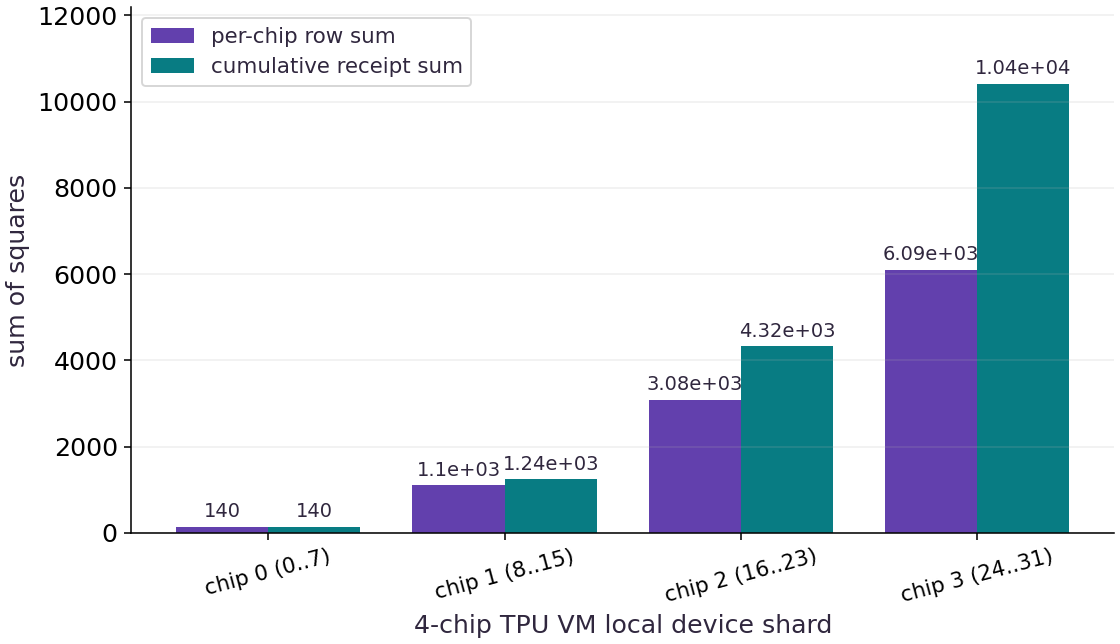

In [5]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis lists each local chip (`chip 0` through `chip 3`) on a 4-device TPU slice (`v5litepod-4` or `v6e-4`). The bars show each chip's local sum of squares (`140`, `1100`, `3084`, `6092`) alongside the cumulative running total across chips (`140`, `1240`, `4324`, `10416`).

### Connect it to the computation

Because `x` is reshaped to `(4, 8)`, every chip executes the same `pmap` program on its own slice of 8 numbers; matching the final cumulative sum of `10416.0` proves all 4 chips participated.

## Compare per-device row sums on a 4-chip TPU slice

Predict: On a 4-chip TPU VM (`v5litepod-4`), why does chip 3 produce a much larger row sum than chip 0?

In [6]:
# Experiment — Compare per-device row sums on a 4-chip TPU slice: Inspecting per_device_sums confirms that distinct shards of x...
# Construct and reshape `x4` into the target tensor dimensions.
x4 = jnp.arange(4 * 8, dtype=jnp.float32).reshape(4, 8)
# Reduce along axis=1 to compute `row_sums_4`.
row_sums_4 = [float(v) for v in jnp.sum(x4 * x4, axis=1)]
# Print the observed values to compare against the expected result.
print("Per-chip sums on a 4-chip slice:", row_sums_4, "Total:", sum(row_sums_4))
# Verify contract: `row_sums_4 == [140.0, 1100.0, 3084.0, 6092.0] and sum(row_sums_4) ==...`.
assert row_sums_4 == [140.0, 1100.0, 3084.0, 6092.0] and sum(row_sums_4) == 10416.0

Per-chip sums on a 4-chip slice: [140.0, 1100.0, 3084.0, 6092.0] Total: 10416.0


Expected: Chip 0 sums 0^2..7^2 = 140.0, chip 1 sums 8^2..15^2 = 1100.0, chip 2 sums 16^2..23^2 = 3084.0, and chip 3 sums 24^2..31^2 = 6092.0 (total 10416.0).

Inspecting `per_device_sums` confirms that distinct shards of `x` were placed and squared on each of the 4 chips.

## Verify teardown confirmation logic

Predict: How can a helper script check that `gcloud compute tpus tpu-vm list` returned zero active VMs?

In [7]:
# Experiment — Verify teardown confirmation logic: Checking gcloud compute tpus tpu-vm list --zone=$ZONE...
def is_tpu_zone_clean(gcloud_list_json):
    # Read or serialize artifact data on disk (`items`).
    items = json.loads(gcloud_list_json)
    # Return `len(items) == 0` to the caller.
    return len(items) == 0

# Verify contract: `is_tpu_zone_clean('[]') is True`.
assert is_tpu_zone_clean("[]") is True
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert is_tpu_zone_clean('[{"name": "jax-tpu-course", "state": "READY"}]') is False
# Print the observed values to compare against the expected result.
print("Teardown verifier passed for empty and non-empty gcloud list outputs.")

Teardown verifier passed for empty and non-empty gcloud list outputs.


Expected: Returns True only when the JSON array from `gcloud compute tpus tpu-vm list --format=json` is empty (`[]`).

Checking `gcloud compute tpus tpu-vm list --zone=$ZONE --format=json` makes teardown verification machine-checkable.

## Your exercise

Compute `closed_form_sum_of_squares(4)` and `closed_form_sum_of_squares(8)`, verify that `closed_form_sum_of_squares(4) == 10416.0`, and assert that `receipt['verified']` is `True`.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `closed_form_sum_of_squares(...)` — Call `closed_form_sum_of_squares` with your updated parameters or inputs from this lesson's workspace.
- `and(...)` — Call `and` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Run `closed_form_sum_of_squares` to compute `s8`.
2. Print the observed values to compare against the expected result.
3. Verify contract: `s4 == 10416.0 and s8 == 85344.0 and (receipt['verified'] is True)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Compute closed_form_sum_of_squares(4) and...
s4 = closed_form_sum_of_squares(...)  # TODO: compute s4
# Run `closed_form_sum_of_squares` to compute `s8`.
s8 = closed_form_sum_of_squares(...)  # TODO: compute s8
# Print the observed values to compare against the expected result.
print("4-chip expected sum:", s4, "8-chip expected sum:", s8, "receipt hash:", receipt["receipt_sha256"])
# Verify contract: `s4 == 10416.0 and s8 == 85344.0 and (receipt['verified'] is True)`.
assert s4  # TODO: complete assertion check
```

In [8]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Compute closed_form_sum_of_squares(4) and...
# s4 = closed_form_sum_of_squares(...)  # TODO: compute s4
# Run `closed_form_sum_of_squares` to compute `s8`.
# s8 = closed_form_sum_of_squares(...)  # TODO: compute s8
# Print the observed values to compare against the expected result.
# print("4-chip expected sum:", s4, "8-chip expected sum:", s8, "receipt hash:", receipt["receipt_sha256"])
# Verify contract: `s4 == 10416.0 and s8 == 85344.0 and (receipt['verified'] is True)`.
# assert s4  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [9]:
# Exercise solution: Compute closed_form_sum_of_squares(4) and...
s4 = closed_form_sum_of_squares(4)
# Run `closed_form_sum_of_squares` to compute `s8`.
s8 = closed_form_sum_of_squares(8)
# Print the observed values to compare against the expected result.
print("4-chip expected sum:", s4, "8-chip expected sum:", s8, "receipt hash:", receipt["receipt_sha256"])
# Verify contract: `s4 == 10416.0 and s8 == 85344.0 and (receipt['verified'] is True)`.
assert s4 == 10416.0 and s8 == 85344.0 and receipt["verified"] is True

4-chip expected sum: 10416.0 8-chip expected sum: 85344.0 receipt hash: 8c6bd0cbe29edc78


## Detect a silent fallback from 4 TPU chips to 1 CPU device · Foundations

Write a check `is_four_chip_tpu_receipt(r)` that returns `True` only when `r['backend'] == 'tpu'`, `r['local_device_count'] == 4`, and `r['observed_total'] == 10416.0`.

Hint: Check all three fields in the receipt dictionary.

### How to write: Detect a silent fallback from 4 TPU chips to 1 CPU device — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `device(...)` — Call `device` with your updated parameters or inputs from this lesson's workspace.
- `is_four_chip_tpu_receipt(...)` — Call `is_four_chip_tpu_receipt` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Detect a silent fallback from 4 TPU chips to 1 CPU device (Foundations): Requiring backend == 'tpu', local_device_count == 4, and the...
2. Return `bool(r['backend'] == 'tpu' and r['local_device_count'] == 4 and np.isclose(r['observed_total'], 10416.0))` to the caller.
3. Evaluate `simulated_tpu` from the current inputs and state.
4. Print the observed values to compare against the expected result.
5. Verify contract: `is_four_chip_tpu_receipt(simulated_tpu) is True`.

**Starter code scaffold (fill in the TODOs):**

```python
# Detect a silent fallback from 4 TPU chips to 1 CPU device (Foundations): Requiring backend == 'tpu', local_device_count == 4, and the...
def is_four_chip_tpu_receipt(r):
    # Return `bool(r['backend'] == 'tpu' and r['local_device_count'] == 4 and np.isclose(r['observed_total'], 10416.0))` to the caller.
    return bool(r["backend"] = ...  # TODO: compute return bool(r["backend"]

# Evaluate `simulated_tpu` from the current inputs and state.
simulated_tpu = ...  # TODO: compute simulated_tpu
# Print the observed values to compare against the expected result.
print("Simulated 4-chip TPU check:", is_four_chip_tpu_receipt(simulated_tpu), "Local CPU check:", is_four_chip_tpu_receipt(receipt))
# Verify contract: `is_four_chip_tpu_receipt(simulated_tpu) is True`.
assert is_four_chip_tpu_receipt(simulated_tpu) is True  # TODO: complete assertion check
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Detect a silent fallback from 4 TPU chips to 1 CPU device (Foundations): Requiring backend == 'tpu', local_device_count == 4, and the...
# def is_four_chip_tpu_receipt(r):
    # Return `bool(r['backend'] == 'tpu' and r['local_device_count'] == 4 and np.isclose(r['observed_total'], 10416.0))` to the caller.
#     return bool(r["backend"] = ...  # TODO: compute return bool(r["backend"]

# Evaluate `simulated_tpu` from the current inputs and state.
# simulated_tpu = ...  # TODO: compute simulated_tpu
# Print the observed values to compare against the expected result.
# print("Simulated 4-chip TPU check:", is_four_chip_tpu_receipt(simulated_tpu), "Local CPU check:", is_four_chip_tpu_receipt(receipt))
# Verify contract: `is_four_chip_tpu_receipt(simulated_tpu) is True`.
# assert is_four_chip_tpu_receipt(simulated_tpu) is True  # TODO: complete assertion check

## Reference reasoning

Requiring `backend == 'tpu'`, `local_device_count == 4`, and the 4-chip `pmap` total prevents a misconfigured environment from passing as a 4-chip TPU run.

In [11]:
# Detect a silent fallback from 4 TPU chips to 1 CPU device (Foundations): Requiring backend == 'tpu', local_device_count == 4, and the...
def is_four_chip_tpu_receipt(r):
    # Return `bool(r['backend'] == 'tpu' and r['local_device_count'] == 4 and np.isclose(r['observed_total'], 10416.0))` to the caller.
    return bool(r["backend"] == "tpu" and r["local_device_count"] == 4 and np.isclose(r["observed_total"], 10416.0))

# Evaluate `simulated_tpu` from the current inputs and state.
simulated_tpu = {"backend": "tpu", "local_device_count": 4, "observed_total": 10416.0}
# Print the observed values to compare against the expected result.
print("Simulated 4-chip TPU check:", is_four_chip_tpu_receipt(simulated_tpu), "Local CPU check:", is_four_chip_tpu_receipt(receipt))
# Verify contract: `is_four_chip_tpu_receipt(simulated_tpu) is True`.
assert is_four_chip_tpu_receipt(simulated_tpu) is True

Simulated 4-chip TPU check: True Local CPU check: False


## Estimate hourly billing savings from immediate teardown · Transfer / diagnosis

If a 4-chip TPU slice costs $4.80$ USD/hour and your verification + experiment takes $0.5$ hours, compute how many USD you save by deleting the VM immediately instead of leaving it idle overnight for $16$ hours.

Hint: Compare `16.0 * 4.80` against `0.5 * 4.80`.

### How to write: Estimate hourly billing savings from immediate teardown — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `teardown(...)` — Call `teardown` with your updated parameters or inputs from this lesson's workspace.
- `round(...)` — Call `round` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Run `round` to compute `saved_usd`.
2. Print the observed values to compare against the expected result.
3. Verify contract: `saved_usd == 74.4`.

**Starter code scaffold (fill in the TODOs):**

```python
# Estimate hourly billing savings from immediate teardown (Transfer / diagnosis): Deleting the Cloud TPU VM immediately after copying...
hourly_rate = ...  # TODO: compute hourly_rate
# Run `round` to compute `saved_usd`.
saved_usd = round(...)  # TODO: compute saved_usd
# Print the observed values to compare against the expected result.
print("Overnight idle cost avoided (USD):", saved_usd)
# Verify contract: `saved_usd == 74.4`.
assert saved_usd  # TODO: complete assertion check
```

In [12]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Estimate hourly billing savings from immediate teardown (Transfer / diagnosis): Deleting the Cloud TPU VM immediately after copying...
# hourly_rate = ...  # TODO: compute hourly_rate
# Run `round` to compute `saved_usd`.
# saved_usd = round(...)  # TODO: compute saved_usd
# Print the observed values to compare against the expected result.
# print("Overnight idle cost avoided (USD):", saved_usd)
# Verify contract: `saved_usd == 74.4`.
# assert saved_usd  # TODO: complete assertion check

## Reference reasoning

Deleting the Cloud TPU VM immediately after copying artifacts back avoids paying for 15.5 idle hours.

In [13]:
# Estimate hourly billing savings from immediate teardown (Transfer / diagnosis): Deleting the Cloud TPU VM immediately after copying...
hourly_rate = 4.80
# Run `round` to compute `saved_usd`.
saved_usd = round((16.0 - 0.5) * hourly_rate, 2)
# Print the observed values to compare against the expected result.
print("Overnight idle cost avoided (USD):", saved_usd)
# Verify contract: `saved_usd == 74.4`.
assert saved_usd == 74.4

Overnight idle cost avoided (USD): 74.4


## Checkpoint

Why does `build_runtime_receipt()` run `jax.pmap` across `jax.local_devices()` and call `jax.block_until_ready` instead of only checking `jax.default_backend()`?

1. Because `jax.default_backend()` deletes the virtual environment
2. Because `jax.pmap` + `jax.block_until_ready` proves that `libtpu` compiled and executed a multi-device XLA computation across every local chip and returned the expected numerical result
3. Because `jax.pmap` automatically deletes the Cloud TPU VM

## Diagnose

If `pip install 'jax[tpu]'` fails to find `libtpu`, verify that `-f https://storage.googleapis.com/jax-releases/libtpu_releases.html` was passed to `pip install` inside the activated `~/jax-tpu-lab/.venv` on the Linux TPU VM.

## Evidence

Keep the JSON runtime receipt (observed_backend, device_count, pmap_sum_of_squares, receipt_sha256) and the 1-chip vs 4-chip vs 8-chip pmap reference values.

## Carry forward

- Always install `jax[tpu]` inside an isolated `~/jax-tpu-lab/.venv` on the TPU VM host.
- Verify `backend`, `local_device_count`, and a synchronized `jax.pmap` sum-of-squares receipt before starting longer experiments.
- Copy your receipt back with `gcloud compute tpus tpu-vm scp`, run `tpu-vm delete`, and confirm `tpu-vm list` is empty.

## Primary references

- [JAX installation for Cloud TPU](https://docs.jax.dev/en/latest/installation.html)
- [Manage Cloud TPU VMs with gcloud](https://cloud.google.com/tpu/docs/managing-tpus-tpu-vm)